# Lab 4 — Electric Fields and Electric Potential  

---

## Overview
In this lab you will **measure electric potential $V(x,y)$** in two different ways and then **compute the electric field** from that potential using 

$$
\vec{E}(x,y) = -\nabla V(x,y).
$$

**Part 1 (Conducting paper mapping):** You will use conducting paper to create two electrode geometries:
1. **Parallel plates** (a 2D model of a parallel-plate capacitor)
2. **Pointed conductor (“lightning rod”)** (a triangle/needle-like electrode)

You will map the potential with a voltmeter, then use **Python or Excel** to estimate $\nabla V$ from your measured grid of $V(x,y)$ values and construct an electric-field map.

**Part 2 (PhET simulation):** You will use **PhET Charges and Fields** to map the potential and electric field for an **electric dipole**. You will compare patterns (equipotentials, field lines, magnitude changes with distance) and connect the dipole to real applications—especially when we move beyond static fields.

**About PhET Interactive Simulations**

PhET Interactive Simulations is a research-based collection of interactive science simulations designed to help students build intuitive, visual understanding of physical concepts by actively exploring cause-and-effect relationships. PhET was founded at the University of Colorado Boulder by physicist Carl Wieman, who was awarded the **2001 Nobel Prize in Physics** (shared with Eric Cornell and Wolfgang Ketterle) for the experimental realization of **Bose–Einstein condensation in dilute gases**. Wieman’s leadership of PhET powerfully illustrates his commitment not only to cutting-edge research, but also to transforming how physics is taught and learned. The simulations are grounded in physics education research and are intentionally designed to promote exploration, sense-making, and conceptual reasoning—making them an ideal complement to hands-on experiments like this lab, where students connect physical measurements, computational analysis, and visualization.


---

## Learning Objectives
By the end of this lab, you should be able to:

1. Explain the relationship between electric potential and electric field:

   $$\vec{E} = -\nabla V.$$

2. Measure (or extract) a 2D potential map $V(x,y)$ on a grid and visualize it using contour/equipotential plots.
3. Compute the electric field from discrete potential data using finite differences:

   $$
   E_x \approx -\frac{\partial V}{\partial x}, \qquad E_y \approx -\frac{\partial V}{\partial y}.
   $$

4. Interpret electric-field maps: direction, relative magnitude, and where fields are strongest.
5. Describe how geometry affects field concentration (e.g., why fields are enhanced near sharp points).
6. Recognize why the **dipole** is a foundational model in E&M, including its role in **radiation and time-varying fields**.

---

## Background Theory

### 1) Electric Potential and Equipotentials
Electric potential $V$ (in volts) is defined so that the potential difference relates to work per unit charge:

$$
\Delta V = -\int_{\mathcal{C}} \vec{E}\cdot d\vec{\ell}.
$$

Surfaces (or curves in 2D) of constant potential are **equipotentials**. The electric field is always **perpendicular** to equipotential curves and points “downhill” in potential.

### 2) Electric Field from the Gradient
In two dimensions,

$$
\nabla V = \left(\frac{\partial V}{\partial x}\right)\hat{i} + \left(\frac{\partial V}{\partial y}\right)\hat{j},
\qquad
\vec{E} = -\nabla V.
$$

So, a rapid change in potential over a short distance implies a large field magnitude:

$$
|\vec{E}| = \sqrt{E_x^2 + E_y^2}.
$$

### 3) Discrete (Grid-Based) Derivatives (Finite Differences)
Your data are measured at grid points $(x_i, y_j)$ with spacing $\Delta x$ and $\Delta y$.

A common numerical estimate at interior points is the **central difference**:

$$
\frac{\partial V}{\partial x}\Big|_{i,j} \approx \frac{V_{i+1,j}-V_{i-1,j}}{2\Delta x}, 
\qquad
\frac{\partial V}{\partial y}\Big|_{i,j} \approx \frac{V_{i,j+1}-V_{i,j-1}}{2\Delta y}.
$$

Then

$$
E_{x,i,j} \approx -\frac{V_{i+1,j}-V_{i-1,j}}{2\Delta x},
\qquad
E_{y,i,j} \approx -\frac{V_{i,j+1}-V_{i,j-1}}{2\Delta y}.
$$

At the boundaries, you will need **one-sided differences**, e.g.

$$
\frac{\partial V}{\partial x}\Big|_{1,j}\approx \frac{V_{2,j}-V_{1,j}}{\Delta x}.
$$

>NOTE: In this lab, the provide Python template use the built-in numerical gradient function to compute $\vec{E} = -\nabla V$ directly from the 2D potential array, but students who prefer Excel (or who want more control) may instead use the finite-difference method explicitly; both approaches are valid, and the finite-difference method can also be implemented manually in Python if desired.

### 4) Why Sharp Points Matter (Lightning Rod Geometry)
For conductors, charges rearrange until the conductor is an equipotential. Near sharp points, surface charge density tends to be higher, producing a stronger electric field nearby. Practically: **fields concentrate near points**, which can promote air ionization and influence discharge paths.

### 5) The Electric Dipole (Why It’s a Big Deal)
A dipole is two equal and opposite charges separated by a small distance. The dipole is the **first nontrivial** charge distribution beyond a single point charge and shows up everywhere:

- **Molecular physics/chemistry:** polar molecules (e.g., water) behave like dipoles in external fields.
- **Materials:** polarization and dielectric response can be modeled using dipoles.
- **Antennas and radiation:** time-varying dipoles are among the simplest sources of **electromagnetic waves** (the “oscillating dipole” is a cornerstone model for radiation).
- **Long-range behavior:** many neutral systems have a leading far-field that looks dipolar (or higher multipoles if symmetry cancels the dipole).

Even though this lab focuses on static patterns, the **dipole is a bridge** to what comes next: induction, waves, and radiation.

---

## Equipment Needed

### Part 1 — Conducting Paper Mapping
- Conducting paper sheets (or conductive mapping paper)
- DC power supply (low voltage, typically a few volts) or  9 V battery
- Electrodes/templates for:
  - Parallel plates
  - Pointed/triangular conductor (“lightning rod”)
- Leads/alligator clips
- Digital multimeter (voltage mode)
- Ruler (for grid spacing)
- Laptop with **Excel or Python** (template provided at the end of the note)

### Part 2 — PhET Simulation
- Computer with internet
- [PhET **Charges and Fields** simulation](https://phet.colorado.edu/en/simulations/charges-and-fields) 

---

## Experimental Procedure

### Part 1 — Mapping $V(x,y)$ on Conducting Paper

#### A. Setup and Calibration
1. Place the conducting paper on the table.
2. Attach the electrodes for the **parallel plate** configuration if not already attached.
3. Connect the power supply across the electrodes (start with a low voltage).
4. Choose a coordinate system: mark an origin and axes along the paper edges.

#### B. Measuring the Potential Map
1. Choose the negative electrode as your reference (ground) for measurements.
2. Set the multimeter to DC voltage.
3. For each grid point $(x_i,y_j)$:
   - Touch the probe tip at the grid point (good contact, consistent pressure).
   - Record $V_{i,j}$ relative to the reference electrode.
4. Collect enough points to see structure clearly (a coarse grid may miss sharp features near the point).

#### C. Repeat for the “Lightning Rod” Geometry
1. Replace the electrodes with the pointed/triangular electrode configuration.
2. Re-use the same reference system if appropriate, but consider taking more measurements near the pointed region where $V$ changes rapidly.
3. Record a new potential map $V(x,y)$.

---

### Part 2 — PhET Dipole Mapping (Charges and Fields)

1. Open the PhET simulation and set up an **electric dipole** (equal and opposite charges separated by a distance).
2. Create a measurement grid in the simulation plane:
   - Choose a spacing and a region large enough to show the overall pattern.
3. Record $V(x,y)$ at grid points (either by reading values directly or by using built-in probes).
4. Use your recorded $V(x,y)$ to compute $\vec{E}(x,y)$ using the same numerical gradient method as Part 1.
5. Compare your computed field vectors to the simulation’s field vectors (direction and relative magnitude).

---

## Data Analysis (Python or Excel)

### 1) Organize Your Data
Create a table of:
- $x_i$, $y_j$
- $V_{i,j}$

If your data are on a rectangular grid, store $V$ as a 2D array with known $\Delta x$, $\Delta y$.

### 2) Plot the Potential Map
- Make a **contour plot** (equipotentials) of $V(x,y)$.
- Label axes with units.

### 3) Compute the Field Components
Using finite differences:

$$
E_x(x_i,y_j)\approx -\frac{V_{i+1,j}-V_{i-1,j}}{2\Delta x}, 
\qquad
E_y(x_i,y_j)\approx -\frac{V_{i,j+1}-V_{i,j-1}}{2\Delta y}.
$$

Then compute magnitude:

$$
|\vec{E}|_{i,j} = \sqrt{E_{x,i,j}^2 + E_{y,i,j}^2}.
$$

### 4) Visualize the Electric Field
- Make a **vector (quiver) plot** of $\vec{E}(x,y)$.
- Optionally overlay field vectors on the equipotential contour plot.
- Consider normalizing vectors for direction-only plots, or use magnitude shading + vectors.

### 5) Compare Geometries
For parallel plates vs pointed conductor vs dipole, compare:
- Equipotential shapes
- Where $|\vec{E}|$ is large
- How quickly $V$ changes with position

---

## Analysis Questions (Include in Your Report)
1. **Orthogonality:** Using your plots, explain how you can verify that $\vec{E}$ is perpendicular to equipotential lines.
2. **Parallel plates:** Identify a region where the field is approximately uniform. What evidence in your $V(x,y)$ data supports this?
3. **Edge effects:** Where do you see fringing fields in the parallel-plate configuration? How do they appear in both $V$ and $\vec{E}$ plots?
4. **Point enhancement:** In the lightning-rod geometry, where is $|\vec{E}|$ largest? Explain qualitatively why geometry causes this.
5. **Dipole symmetry:** Describe the symmetry of the dipole potential and field. How does the pattern differ from a single point charge?
6. **Static to dynamic connection:** An oscillating dipole is a classic radiation source. Based on your static dipole field pattern, what features do you think might matter when the dipole moment changes with time?

---

## Discussion
In your discussion section, connect your results to physics meaning:

- Describe how the **shape of conductors** controls equipotentials and concentrates fields.
- Explain differences between **uniform-field regions** and **high-gradient regions**.
- Discuss limitations: grid resolution, probe contact variability, and how numerical derivatives amplify measurement noise (small errors in $V$ can create noticeable variation in $\vec{E}$).
- Highlight the importance of the **dipole**:
  - Many neutral systems have dipole-like behavior at moderate distances.
  - Dipoles are central to polarization in materials and to how matter responds to fields.
  - In time-varying cases, dipoles connect directly to **electromagnetic waves and antennas** (one of the simplest and most important radiation models in E&M).

---

## Report Checklist (Beyond the standard expexted content)
Include:
- A labeled photo of each setup (parallel plates, lightning rod)
- Example Tables of $V(x,y)$ data (no need to show all your data)
- Equipotential plots for each geometry
- Computed field vector plots for each geometry
- Responses to analysis questions

---

## Data Table Template

**Table 1 — Electric Potential and Field Mapping Data**

<table style="border-collapse:collapse; width:60%; font-family:Arial, sans-serif; font-size:14px;">
  <thead>
    <tr style="background:#f2f2f2;">
      <th style="border:1px solid #999; padding:8px; text-align:center;">$x$ (cm)</th>
      <th style="border:1px solid #999; padding:8px; text-align:center;">$y$ (cm)</th>
      <th style="border:1px solid #999; padding:8px; text-align:center;">$V$ (V)</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #999; padding:6px; text-align:center;">0.0</td>
      <td style="border:1px solid #999; padding:6px; text-align:center;">0.0</td>
      <td style="border:1px solid #999; padding:6px; text-align:center;">5.00</td>
    </tr>
    <tr>
      <td style="border:1px solid #999; padding:6px; text-align:center;">1.0</td>
      <td style="border:1px solid #999; padding:6px; text-align:center;">0.0</td>
      <td style="border:1px solid #999; padding:6px; text-align:center;">4.80</td>
    </tr>
    <tr>
      <td style="border:1px solid #999; padding:6px; text-align:center;">2.0</td>
      <td style="border:1px solid #999; padding:6px; text-align:center;">0.0</td>
      <td style="border:1px solid #999; padding:6px; text-align:center;">4.60</td>
    </tr>
    <tr>
      <td style="border:1px solid #999; padding:6px; text-align:center;">0.0</td>
      <td style="border:1px solid #999; padding:6px; text-align:center;">1.0</td>
      <td style="border:1px solid #999; padding:6px; text-align:center;">4.90</td>
    </tr>
    <tr>
      <td style="border:1px solid #999; padding:6px; text-align:center;">1.0</td>
      <td style="border:1px solid #999; padding:6px; text-align:center;">1.0</td>
      <td style="border:1px solid #999; padding:6px; text-align:center;">4.70</td>
    </tr>
  </tbody>
</table>


>Note:  
>- $x$ and $y$ are measured relative to the chosen origin on the conducting paper or simulation grid.  

## Python Template

If you want to test this script, you can download this sample data file:

In [4]:
from IPython.display import FileLink

display(FileLink('potential_map.csv', result_html_prefix="Download: "))

/Users/kim/Documents/Modulearn-git/books/university-physics-II-lab/lab4/potential_map.csv

>NOTE: The file is a comma-separated values (CSV) file in which the first column contains the $x$-coordinate (cm), the second column contains the $y$-coordinate (cm), and the third column contains the electric potential $V$ (volts) measured at that location.

Grid spacing: dx = 1.000e-02 m, dy = 1.000e-02 m


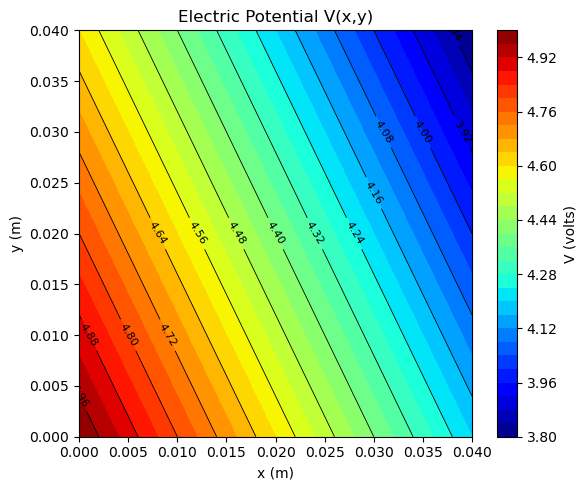

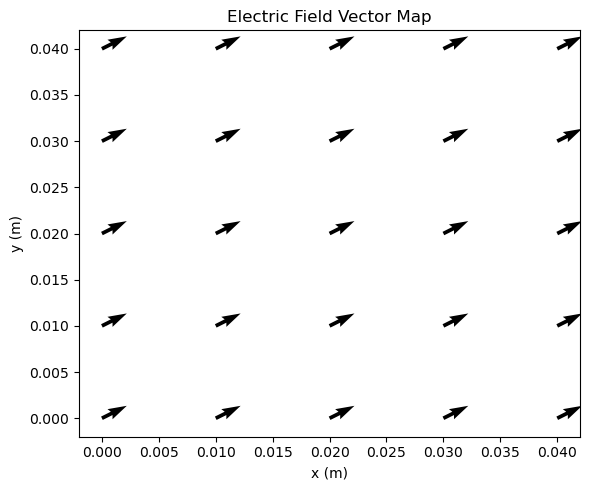

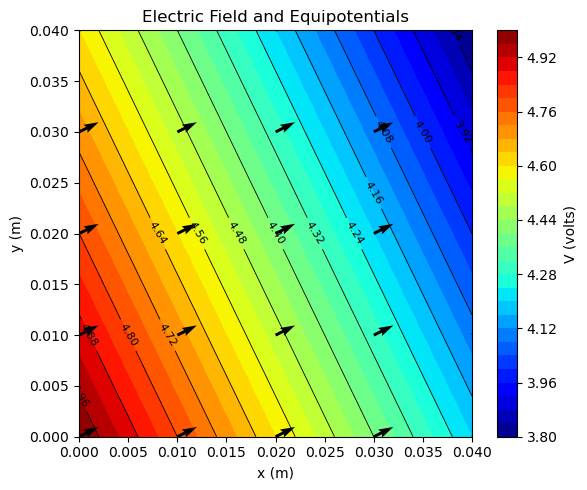

Analysis complete. Results saved to electric_field_results.csv.


In [3]:
# --------------------------------------------------
# Lab 4 — Electric Potential to Electric Field
# Python Analysis Template
# --------------------------------------------------

%reset -f

# -----------------------------
# Imports
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load data if in CSV format...otherwise just code directly
# -----------------------------
# Expected CSV format:
# x_cm, y_cm, V
#
# Example:
# 0.0, 0.0, 2.45
# 1.0, 0.0, 2.30
# 0.0, 1.0, 2.10
#
# Update the filename as needed

data = pd.read_csv("potential_map.csv")

# -----------------------------
# Extract columns
# -----------------------------
x_cm = data["x_cm"].values
y_cm = data["y_cm"].values
V    = data["V"].values

# Convert cm → m
x = x_cm * 1e-2
y = y_cm * 1e-2

# -----------------------------
# Create grid
# -----------------------------
# Assumes data lie on a rectangular grid

x_unique = np.unique(x)
y_unique = np.unique(y)

X, Y = np.meshgrid(x_unique, y_unique)

# Reshape potential into 2D array
V_grid = V.reshape(len(y_unique), len(x_unique))

# Grid spacing
dx = x_unique[1] - x_unique[0]
dy = y_unique[1] - y_unique[0]

print(f"Grid spacing: dx = {dx:.3e} m, dy = {dy:.3e} m")

# -----------------------------
# Compute electric field
# E = -grad(V)
# -----------------------------
Ey, Ex = np.gradient(V_grid, dy, dx)

Ex = -Ex
Ey = -Ey

E_mag = np.sqrt(Ex**2 + Ey**2)

# -----------------------------
# Plot equipotential map (colored background)
# -----------------------------
plt.figure(figsize=(6,5))

filled = plt.contourf(
    X, Y, V_grid,
    levels=30,
    cmap="jet"
)

# Optional: overlay contour lines
contours = plt.contour(
    X, Y, V_grid,
    levels=15,
    colors="black",
    linewidths=0.6
)
plt.clabel(contours, inline=True, fontsize=8)

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Electric Potential V(x,y)")
plt.colorbar(filled, label="V (volts)")
plt.tight_layout()
plt.show()


# -----------------------------
# Plot electric field vectors
# -----------------------------
plt.figure(figsize=(6,5))
plt.quiver(X, Y, Ex, Ey)
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Electric Field Vector Map")
plt.tight_layout()
plt.show()

# -----------------------------
# Combined plot: equipotentials + E-field (colored background)
# -----------------------------
plt.figure(figsize=(6,5))

# Filled contour for potential (color background)
filled = plt.contourf(
    X, Y, V_grid,
    levels=30,
    cmap="jet"
)

# Equipotential lines
contours = plt.contour(
    X, Y, V_grid,
    levels=15,
    colors="black",
    linewidths=0.6
)
plt.clabel(contours, inline=True, fontsize=8)

# Electric field vectors
plt.quiver(X, Y, Ex, Ey, color="black")

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Electric Field and Equipotentials")
plt.colorbar(filled, label="V (volts)")
plt.tight_layout()
plt.show()


# -----------------------------
# Save processed data (optional)
# -----------------------------
output = pd.DataFrame({
    "x_m": X.flatten(),
    "y_m": Y.flatten(),
    "V": V_grid.flatten(),
    "Ex": Ex.flatten(),
    "Ey": Ey.flatten(),
    "|E|": E_mag.flatten()
})

output.to_csv("electric_field_results.csv", index=False)

print("Analysis complete. Results saved to electric_field_results.csv.")
